# 01 — Data Quality EDA

**Goal:** Understand the shape, completeness, and reliability of collected price data before any modelling.

Questions answered here:
- How many products and observations do we have?
- How are observations distributed across retailers and sources?
- Are there missing values in critical fields?
- Are there suspicious price outliers?
- Do any products have duplicate observations within the dedup window?
- What is the observation density per product (key for feature reliability)?

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.db_utils import get_engine, load_price_history

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_colwidth', 60)
engine = get_engine()

## 1. Load data

In [2]:
# NOTE: dataset contains both seed (synthetic) and extension (real) observations.
# source='seed' — 90-day synthetic history generated by backend/app/db/seed.py
# source='extension' — real observations captured by the Chrome extension
# Both are included here for EDA; production training will filter to source='extension'
# once enough real data has accumulated.

df = load_price_history(engine)

print(f'Rows: {len(df):,}  |  Products: {df["product_id"].nunique()}  |  '
      f'Date range: {df["observed_at"].min().date()} → {df["observed_at"].max().date()}')
df.head()

## 2. Overview

In [3]:
print('--- Shape ---')
print(df.shape)
print('\n--- dtypes ---')
print(df.dtypes)
print('\n--- Retailers ---')
print(df.groupby('retailer')['product_id'].nunique().rename('products'))
print('\n--- Source breakdown ---')
print(df.groupby('source').size().rename('observations'))

--- Shape ---
(124, 11)

--- dtypes ---
id                           object
product_id                   object
price                       float64
currency                        str
availability                    str
observed_at     datetime64[us, UTC]
source                          str
title                           str
brand                           str
category                        str
retailer                        str
dtype: object

--- Retailers ---
retailer
Amazon      17
Best Buy     5
Name: products, dtype: int64

--- Source breakdown ---
source
extension      3
seed         121
Name: observations, dtype: int64


## 3. Missing value analysis

In [4]:
missing = df.isnull().sum().rename('null_count')
missing_pct = (df.isnull().mean() * 100).rename('null_pct').round(2)
missing_df = pd.concat([missing, missing_pct], axis=1)
missing_df = missing_df[missing_df['null_count'] > 0]

if missing_df.empty:
    print('No missing values in any column.')
else:
    print('Columns with missing values:')
    display(missing_df)

Columns with missing values:


,null_count,null_pct
brand,1,0.81
category,3,2.42


## 4. Price outlier detection

Suspected price outliers (>80% from product median): 0


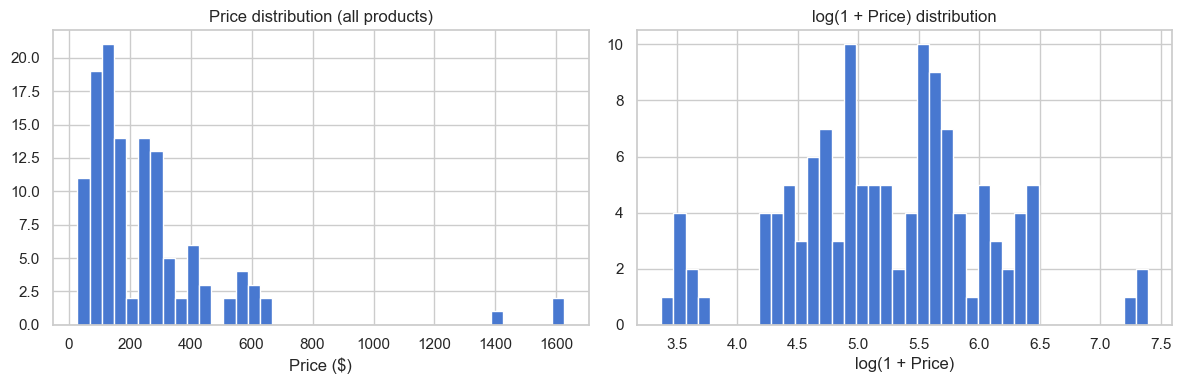

In [5]:
# Flag rows where price deviates >80% from that product's median price
medians = df.groupby('product_id')['price'].transform('median')
df['price_vs_median_pct'] = (df['price'] - medians) / medians
outliers = df[df['price_vs_median_pct'].abs() > 0.80]

print(f'Suspected price outliers (>80% from product median): {len(outliers)}')
if not outliers.empty:
    display(outliers[['title', 'retailer', 'price', 'price_vs_median_pct', 'observed_at', 'source']].head(20))

# Overall price distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['price'].hist(bins=40, ax=axes[0])
axes[0].set_title('Price distribution (all products)')
axes[0].set_xlabel('Price ($)')

np.log1p(df['price']).hist(bins=40, ax=axes[1])
axes[1].set_title('log(1 + Price) distribution')
axes[1].set_xlabel('log(1 + Price)')
plt.tight_layout()
plt.show()

## 5. Observations per product

Observations per product:
                                                                                                                                                                           title retailer  obs_count
                                                                                                                                Logitech MX Master 3S Wireless Performance Mouse   Amazon         11
                                                                                                                  Sony - WH-1000XM5 Wireless Noise-Canceling Over-Ear Headphones Best Buy         11
                                                                                                                        Samsung Galaxy Buds2 Pro True Wireless Bluetooth Earbuds   Amazon          9
                                                                                                                       LG - 27GP850-B 27" Ultragear QHD IPS Gaming Monitor 165Hz Best Buy 

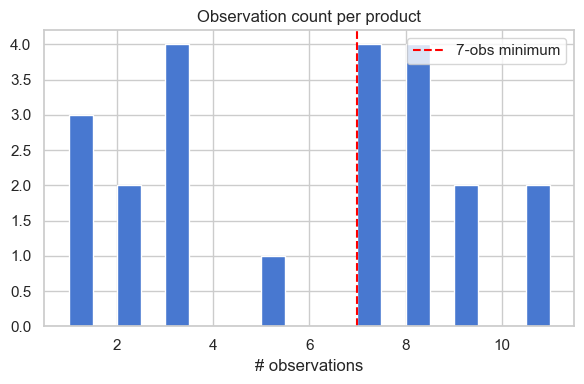

In [6]:
obs_per_product = df.groupby(['product_id', 'title', 'retailer']).size().reset_index(name='obs_count')
obs_per_product = obs_per_product.sort_values('obs_count', ascending=False)

print('Observations per product:')
print(obs_per_product[['title', 'retailer', 'obs_count']].to_string(index=False))

print(f'\nProducts with < 7 observations (insufficient for reliable ML): '
      f"{(obs_per_product['obs_count'] < 7).sum()}")

fig, ax = plt.subplots(figsize=(6, 4))
obs_per_product['obs_count'].hist(bins=20, ax=ax)
ax.axvline(7, color='red', linestyle='--', label='7-obs minimum')
ax.set_title('Observation count per product')
ax.set_xlabel('# observations')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Duplicate / near-duplicate detection

In [7]:
# Check if any two observations for the same product have the same price
# and are within 6 hours of each other (dedup window)
df_sorted = df.sort_values(['product_id', 'observed_at'])
df_sorted['prev_price'] = df_sorted.groupby('product_id')['price'].shift(1)
df_sorted['prev_time']  = df_sorted.groupby('product_id')['observed_at'].shift(1)
df_sorted['time_diff_h'] = (
    (df_sorted['observed_at'] - df_sorted['prev_time'])
    .dt.total_seconds() / 3600
)

near_dups = df_sorted[
    (df_sorted['price'] == df_sorted['prev_price']) &
    (df_sorted['time_diff_h'] <= 6)
]
print(f'Near-duplicate observations (same price, ≤6h apart): {len(near_dups)}')
if not near_dups.empty:
    print('These should not exist if dedup logic is working correctly.')
    display(near_dups[['title', 'price', 'observed_at', 'time_diff_h', 'source']].head(10))

Near-duplicate observations (same price, ≤6h apart): 0


## 7. Data quality summary

In [8]:
print('=== DATA QUALITY SUMMARY ===')
print(f'Total products           : {df["product_id"].nunique()}')
print(f'Total price observations : {len(df):,}')
print(f'Date range               : {df["observed_at"].min().date()} → {df["observed_at"].max().date()}')
print(f'Retailers                : {", ".join(df["retailer"].unique())}')
print(f'Sources                  : {", ".join(df["source"].unique())}')
print(f'Missing values           : {df.isnull().sum().sum()} total')
print(f'Price outliers (>80%)    : {len(outliers)}')
print(f'Near-duplicates          : {len(near_dups)}')
print(f'Products < 7 obs         : {(obs_per_product["obs_count"] < 7).sum()}')

=== DATA QUALITY SUMMARY ===
Total products           : 22
Total price observations : 124
Date range               : 2026-02-12 → 2026-05-12
Retailers                : Amazon, Best Buy
Sources                  : seed, extension
Missing values           : 4 total
Price outliers (>80%)    : 0
Near-duplicates          : 0
Products < 7 obs         : 10
